In [1]:
# =============================================================================
# PHASE 2 — US FEATURE ENGINEERING
# Macro-Market Regime Detection System
# =============================================================================
# Transforms the raw daily dataset from Phase 1 into a model-ready feature
# matrix: returns, rolling volatility
# , GARCH conditional volatility, yield
# curve slope, inflation transformations, and z-scored versions of everything.
#
# Input:  data/processed/us_combined_daily.parquet  (from Phase 1)
# Output: data/processed/us_features_daily.parquet   (ready for Phase 3 modelling)
# =============================================================================

In [2]:
# -----------------------------------------------------------------------------
# CELL 1 — Imports & load Phase 1 output
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

pd.set_option("display.max_columns", None)

PROCESSED_DIR = "data/processed"
df = pd.read_parquet(f"{PROCESSED_DIR}/us_combined_daily.parquet")
df = df.sort_index()

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(df.tail())

Loaded 6914 rows x 10 columns
Date range: 1999-01-04 to 2026-06-29
                  SP500        VIX      CPI  FEDFUNDS  DGS10  DGS2  T5YIE  \
date                                                                        
2026-06-23  7365.459961  19.490000  333.979      3.63   4.50  4.16   2.24   
2026-06-24  7358.220215  18.629999  333.979      3.63   4.41  4.11   2.19   
2026-06-25  7357.490234  18.889999  333.979      3.63   4.40  4.09   2.23   
2026-06-26  7354.020020  18.410000  333.979      3.63   4.38  4.07   2.21   
2026-06-29  7440.430176  17.650000  333.979      3.63   4.38  4.07   2.24   

            BAA10Y    INDPRO  PHILLY_FED  
date                                      
2026-06-23    1.51  102.6475        10.3  
2026-06-24    1.52  102.6475        10.3  
2026-06-25    1.54  102.6475        10.3  
2026-06-26    1.56  102.6475        10.3  
2026-06-29    1.56  102.6475        10.3  


In [3]:
# -----------------------------------------------------------------------------
# CELL 2 — Market-based features: returns, realized volatility, drawdown
# -----------------------------------------------------------------------------
feat = pd.DataFrame(index=df.index)

# Daily log returns — the standard input for vol modelling and GARCH
feat["sp500_ret"] = np.log(df["SP500"]).diff()

# Rolling realized volatility, annualized (252 trading days/year)
# 20d = roughly 1 trading month, 60d = roughly 1 trading quarter
feat["realized_vol_20d"] = feat["sp500_ret"].rolling(20).std() * np.sqrt(252)
feat["realized_vol_60d"] = feat["sp500_ret"].rolling(60).std() * np.sqrt(252)

# VIX level and 20-day rate of change — VIX is already a vol measure, but
# its *trend* (rising vs falling fear) is informative on its own
feat["vix_level"] = df["VIX"]
feat["vix_change_20d"] = df["VIX"].diff(20)

# Equity drawdown from rolling all-time high (up to each point in time)
# This directly captures "are we in a sell-off" without needing returns
rolling_max = df["SP500"].cummax()
feat["sp500_drawdown"] = (df["SP500"] / rolling_max) - 1  # negative = below high

print(feat[["sp500_ret", "realized_vol_20d", "vix_level", "sp500_drawdown"]].describe())

         sp500_ret  realized_vol_20d    vix_level  sp500_drawdown
count  6911.000000       6873.000000  6914.000000     6913.000000
mean      0.000260          0.163753    19.995755       -0.124883
std       0.012136          0.104099     8.214450        0.127492
min      -0.127652          0.032837     9.140000       -0.567754
25%      -0.004813          0.099158    14.180000       -0.208326
50%       0.000634          0.139054    18.134999       -0.079015
75%       0.005979          0.197611    23.547500       -0.014176
max       0.109572          0.978970    82.690002        0.000000


In [4]:
# -----------------------------------------------------------------------------
# CELL 3 — GARCH(1,1) conditional volatility
# -----------------------------------------------------------------------------
# A model-based volatility estimate, independent of the simple rolling
# windows above. This is the volatility-modelling component from the
# project plan and gives a smoother, more theoretically grounded vol
# series than rolling std — and acts as a cross-check against realized_vol.
#
# arch_model expects returns scaled roughly in percent (not decimals) for
# numerical stability, so we multiply by 100 and divide the output back down.

returns_pct = (feat["sp500_ret"].dropna()) * 100

garch_model = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="t")
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

# Conditional volatility, annualized, rescaled back from percent
garch_cond_vol = garch_fit.conditional_volatility / 100 * np.sqrt(252)
feat["garch_vol"] = garch_cond_vol.reindex(feat.index)

print("\nGARCH conditional volatility (annualized) — describe:")
print(feat["garch_vol"].describe())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                    sp500_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9402.38
Distribution:      Standardized Student's t   AIC:                           18814.8
Method:                  Maximum Likelihood   BIC:                           18849.0
                                              No. Observations:                 6911
Date:                      Tue, Jun 30 2026   Df Residuals:                     6910
Time:                              18:38:01   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [5]:
# -----------------------------------------------------------------------------
# CELL 4 — Rates, curve, and credit features
# -----------------------------------------------------------------------------
# Yield curve slope: 10Y minus 2Y. Negative = inverted curve, a classic
# recession-warning signal and a strong regime-discriminating feature.
feat["curve_slope_10y2y"] = df["DGS10"] - df["DGS2"]

# Level and 60-day change in the policy rate — captures both "where rates
# are" and "which direction the Fed is moving," which matter differently
# for regime classification (e.g. high-and-falling vs high-and-rising).
feat["fed_funds_level"] = df["FEDFUNDS"]
feat["fed_funds_change_60d"] = df["FEDFUNDS"].diff(60)

# Credit spread level and change — widening = deteriorating risk appetite
feat["credit_spread"] = df["BAA10Y"]
feat["credit_spread_change_20d"] = df["BAA10Y"].diff(20)

# Market-implied inflation expectations (only available from 2003 onward)
feat["breakeven_inflation"] = df["T5YIE"]

print(feat[["curve_slope_10y2y", "fed_funds_level", "credit_spread",
            "breakeven_inflation"]].describe())

       curve_slope_10y2y  fed_funds_level  credit_spread  breakeven_inflation
count        6914.000000      6914.000000    6914.000000          5910.000000
mean            1.022345         2.143337       2.448865             1.963526
std             0.960206         2.060393       0.731623             0.567375
min            -1.080000         0.050000       1.360000            -2.240000
25%             0.210000         0.160000       1.890000             1.640000
50%             0.950000         1.550000       2.300000             2.010000
75%             1.850000         4.290000       2.860000             2.360000
max             2.910000         6.540000       6.160000             3.590000


In [6]:
# -----------------------------------------------------------------------------
# CELL 5 — Inflation and growth features
# -----------------------------------------------------------------------------
# CPI is a level (index), not a rate — convert to year-over-year % change,
# which is what "inflation" actually means in regime-classification terms.
# Note: df is daily (CPI forward-filled from monthly), so a 252-trading-day
# shift approximates a 12-month lookback.
feat["cpi_yoy"] = df["CPI"].pct_change(252) * 100

# Industrial production YoY — lagging growth proxy
feat["indpro_yoy"] = df["INDPRO"].pct_change(252) * 100

# Philly Fed Manufacturing Index — already a diffusion index (mean-reverting
# around 0), so use the level directly rather than a % change transform
feat["philly_fed"] = df["PHILLY_FED"]

print(feat[["cpi_yoy", "indpro_yoy", "philly_fed"]].describe())

           cpi_yoy   indpro_yoy   philly_fed
count  6662.000000  6662.000000  6914.000000
mean      2.602400     0.586656     7.206465
std       1.717756     4.215844    16.164423
min      -1.958761   -17.413567   -58.700000
25%       1.669817    -0.922634    -1.300000
50%       2.391201     1.626376     8.700000
75%       3.338550     2.880394    17.300000
max       8.979361    16.552135    48.800000


In [7]:
# -----------------------------------------------------------------------------
# CELL 6 — Drop warm-up NaNs from rolling/diff operations
# -----------------------------------------------------------------------------
# Rolling windows, diffs, and YoY calculations all introduce NaNs at the
# start of the series. Drop rows where the core features aren't yet
# computable. breakeven_inflation will still have its own NaNs pre-2003 —
# leave those as-is and handle in Phase 3 (e.g. exclude pre-2003 from any
# model run that uses this feature, or impute/drop the column for early-period
# analysis).

core_cols = [c for c in feat.columns if c != "breakeven_inflation"]
before = len(feat)
feat_clean = feat.dropna(subset=core_cols)
after = len(feat_clean)

print(f"Dropped {before - after} warm-up rows (rolling windows / YoY calcs need history first)")
print(f"Remaining: {after} rows, from {feat_clean.index.min().date()} to {feat_clean.index.max().date()}")
print("\nRemaining NaNs (breakeven_inflation expected, pre-2003):")
print(feat_clean.isna().sum())

Dropped 277 warm-up rows (rolling windows / YoY calcs need history first)
Remaining: 6637 rows, from 2000-01-03 to 2026-05-22

Remaining NaNs (breakeven_inflation expected, pre-2003):
sp500_ret                     0
realized_vol_20d              0
realized_vol_60d              0
vix_level                     0
vix_change_20d                0
sp500_drawdown                0
garch_vol                     0
curve_slope_10y2y             0
fed_funds_level               0
fed_funds_change_60d          0
credit_spread                 0
credit_spread_change_20d      0
breakeven_inflation         752
cpi_yoy                       0
indpro_yoy                    0
philly_fed                    0
dtype: int64


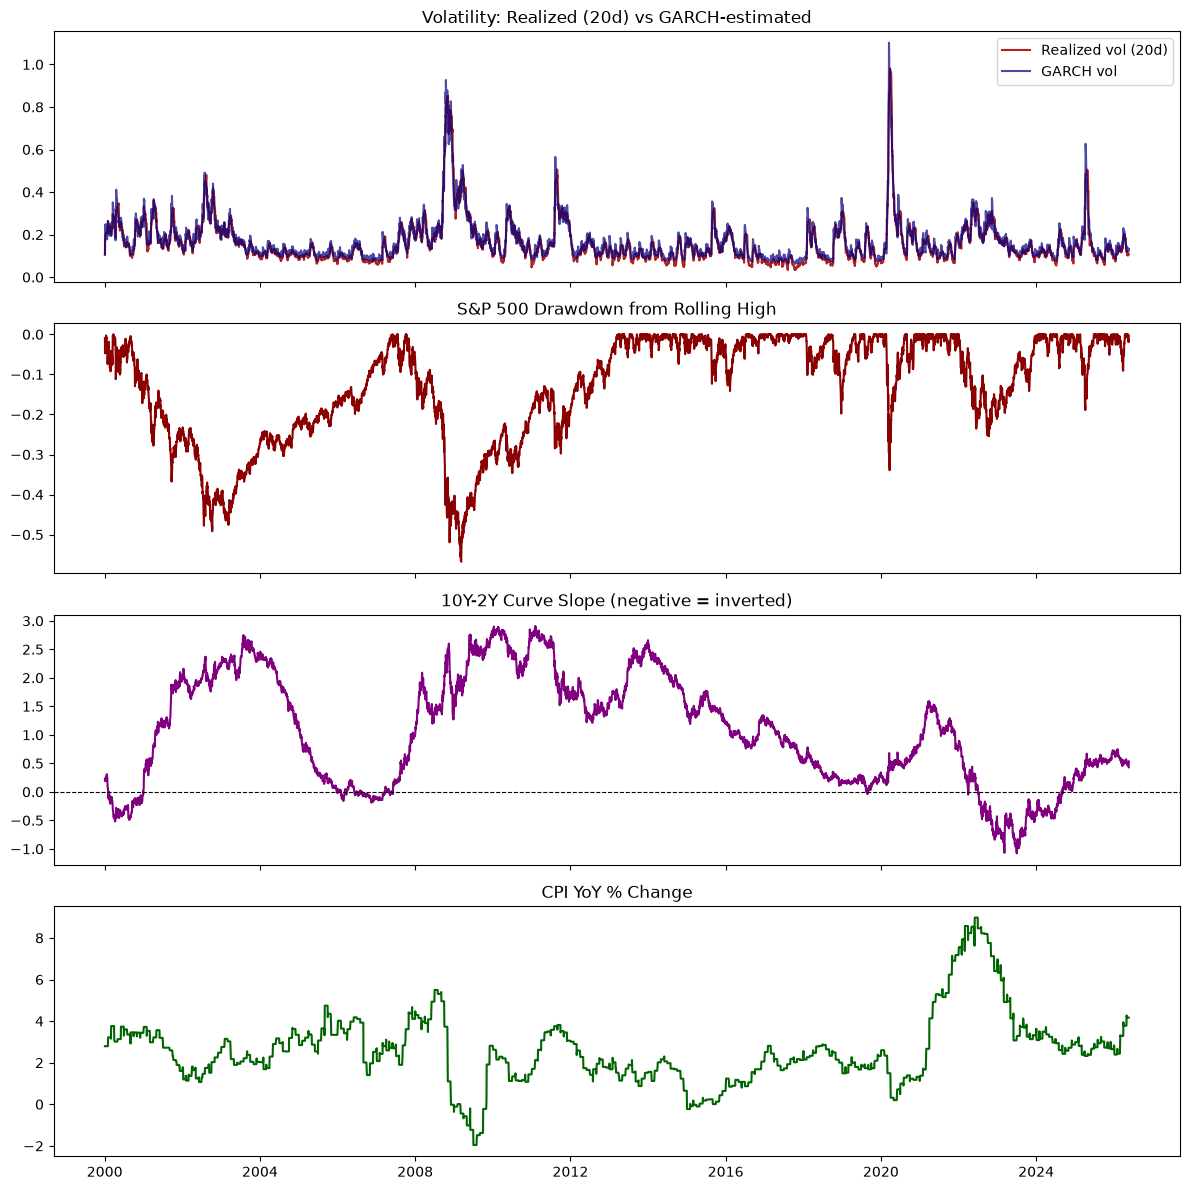

In [8]:
# -----------------------------------------------------------------------------
# CELL 7 — Sanity check: plot key features against known historical events
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(feat_clean.index, feat_clean["realized_vol_20d"], color="firebrick", label="Realized vol (20d)")
axes[0].plot(feat_clean.index, feat_clean["garch_vol"], color="navy", alpha=0.7, label="GARCH vol")
axes[0].set_title("Volatility: Realized (20d) vs GARCH-estimated")
axes[0].legend()

axes[1].plot(feat_clean.index, feat_clean["sp500_drawdown"], color="darkred")
axes[1].set_title("S&P 500 Drawdown from Rolling High")

axes[2].plot(feat_clean.index, feat_clean["curve_slope_10y2y"], color="purple")
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("10Y-2Y Curve Slope (negative = inverted)")

axes[3].plot(feat_clean.index, feat_clean["cpi_yoy"], color="darkgreen")
axes[3].set_title("CPI YoY % Change")

plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/phase2_feature_sanity_check.png", dpi=120)
plt.show()

# What to look for:
# - Vol panel: both lines should spike together in 2008 and 2020; GARCH
#   should look smoother than realized vol, not noisier
# - Drawdown panel: sharp drops to roughly -55% (2008-09) and -34% (2020)
# - Curve panel: should dip negative around 2000, 2006-07, and 2022-23
#   (all historically preceded recessions/regime shifts)
# - CPI panel: should spike to ~9% around mid-2022 (the post-COVID inflation surge)

In [9]:
# -----------------------------------------------------------------------------
# CELL 8 — Z-score (standardize) all features
# -----------------------------------------------------------------------------
# Regimes shouldn't depend on raw units — a feature measured in percentage
# points (CPI YoY) and one measured in index points (VIX) need to be on a
# comparable scale before PCA/clustering/HMM touch them. Standardize using
# only the clean (NaN-free) feature set; breakeven_inflation is z-scored on
# its own non-null subset and will retain NaNs for pre-2003 dates.

def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

feat_z = feat_clean.apply(zscore)

print("Z-scored feature matrix — describe (mean ~0, std ~1 expected):")
print(feat_z.describe().T[["mean", "std", "min", "max"]])

Z-scored feature matrix — describe (mean ~0, std ~1 expected):
                                  mean  std        min        max
sp500_ret                 2.462330e-17  1.0 -10.509623   8.983649
realized_vol_20d          2.055510e-16  1.0  -1.232462   7.715728
realized_vol_60d         -8.564625e-17  1.0  -1.235441   5.965095
vix_level                 0.000000e+00  1.0  -1.286120   7.555833
vix_change_20d           -1.712925e-17  1.0  -7.804399  11.993162
sp500_drawdown            1.370340e-16  1.0  -3.415504   1.001731
garch_vol                -3.083265e-16  1.0  -1.084538   9.309195
curve_slope_10y2y        -6.851700e-17  1.0  -2.211229   1.920204
fed_funds_level           8.564625e-17  1.0  -0.978631   2.228738
fed_funds_change_60d      3.425850e-17  1.0  -3.960682   3.437585
credit_spread            -2.740680e-16  1.0  -1.482097   4.981341
credit_spread_change_20d -1.070578e-17  1.0  -5.322846  10.013718
breakeven_inflation      -2.318168e-16  1.0  -7.399894   2.867809
cpi_yoy      

In [10]:
# -----------------------------------------------------------------------------
# CELL 9 — Save Phase 2 outputs
# -----------------------------------------------------------------------------
# Save both the raw (unscaled, interpretable) features and the z-scored
# version. You'll want the raw version later for the dashboard's
# "explanation panel" (e.g. "VIX is at 28, well above its historical
# average of 20"), and the z-scored version for PCA/clustering/HMM in Phase 3.

feat_clean.to_parquet(f"{PROCESSED_DIR}/us_features_daily.parquet")
feat_clean.to_csv(f"{PROCESSED_DIR}/us_features_daily.csv")

feat_z.to_parquet(f"{PROCESSED_DIR}/us_features_zscored.parquet")
feat_z.to_csv(f"{PROCESSED_DIR}/us_features_zscored.csv")

print(f"Saved raw features: {feat_clean.shape[0]} rows x {feat_clean.shape[1]} columns")
print(f"Saved z-scored features: {feat_z.shape[0]} rows x {feat_z.shape[1]} columns")
print("\nFeature list:")
for col in feat_clean.columns:
    print(f"  - {col}")

print("\nPhase 2 complete. Move to Phase 3: PCA + K-means + HMM modelling.")

Saved raw features: 6637 rows x 16 columns
Saved z-scored features: 6637 rows x 16 columns

Feature list:
  - sp500_ret
  - realized_vol_20d
  - realized_vol_60d
  - vix_level
  - vix_change_20d
  - sp500_drawdown
  - garch_vol
  - curve_slope_10y2y
  - fed_funds_level
  - fed_funds_change_60d
  - credit_spread
  - credit_spread_change_20d
  - breakeven_inflation
  - cpi_yoy
  - indpro_yoy
  - philly_fed

Phase 2 complete. Move to Phase 3: PCA + K-means + HMM modelling.
